In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [249]:
data = pd.read_csv('../consolidated_dataset/consolidated.csv')

In [250]:
for i in range(data.shape[0]):
    if data.loc[i, 'price_change'] == -1:
        data.loc[i, 'price_change'] = 0

In [251]:
from random import sample, seed

seed(123)

df = []

for d in data.itertuples():
    a = list(d[1:349])
    a = sample(a, len(a))
    a.append(d[1396])
    df.append(a)

    a = list(d[349:697])
    a = sample(a, len(a))
    a.append(d[1396])
    df.append(a)

    a = list(d[697:1045])
    a = sample(a, len(a))
    a.append(d[1396])
    df.append(a)

    a = list(d[1045:1393])
    a = sample(a, len(a))
    a.append(d[1396])
    df.append(a)

    # a = list(d[1:466])
    # a = sample(a, 465)
    # a.append(d[1396])
    # df.append(a)

    # a = list(d[466:931])
    # a = sample(a, 465)
    # a.append(d[1396])
    # df.append(a)

    # a = list(d[931:1396])
    # a = sample(a, 465)
    # a.append(d[1396])
    # df.append(a)

df = pd.DataFrame(df)
df.columns = data.columns.values[0:349]
df.rename(columns={'s_349': 'price_change'}, inplace=True)
data = df.sample(frac=1.0, random_state=0)
data.reset_index(drop=True, inplace=True)
data

,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,...,s_340,s_341,s_342,s_343,s_344,s_345,s_346,s_347,s_348,price_change
0,0.0000,0.0000,0.0000,-0.3182,0.4404,-0.3400,0.0000,0.7650,0.0000,0.8591,...,0.0000,0.0000,0.5859,-0.6369,0.0000,0.6369,0.0000,0.6808,-0.1027,1
1,0.0000,0.0000,0.8908,0.0000,0.0000,0.0000,0.0000,-0.2263,0.0000,0.6696,...,0.3612,0.0000,0.9356,0.6808,0.6486,0.6588,0.6369,0.5233,0.5106,1
2,0.0000,0.0000,0.0000,0.2960,0.0000,0.4215,0.0000,0.4215,0.0000,-0.1027,...,0.0000,0.3818,0.9686,0.0000,0.7650,0.0772,0.7088,0.8860,-0.0516,0
3,0.2960,0.5093,0.0000,0.8356,0.8689,0.4588,0.4588,0.0000,0.2500,0.1280,...,0.0000,0.2023,0.3818,0.6486,0.2732,0.0000,0.0000,0.7605,0.0000,0
4,0.0000,0.0000,0.0941,-0.1027,-0.2960,-0.3612,0.0000,0.0000,0.8873,0.0000,...,-0.3400,0.0000,-0.1010,0.1027,0.2500,0.0000,0.0000,-0.2495,-0.2732,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,-0.7943,0.1154,-0.0516,0.3818,0.6705,0.0000,0.5267,-0.4215,0.0000,0.5574,...,-0.5267,0.0000,0.0000,0.0000,0.4588,0.3595,0.0000,0.7579,0.4898,0
788,0.7418,0.0000,-0.5106,0.7003,-0.5927,-0.5106,0.1531,0.2500,0.0000,0.4926,...,0.5244,0.0000,0.0000,0.1531,-0.2960,0.0000,0.8367,-0.9023,0.5484,1
789,0.0000,0.7783,0.6697,0.0000,0.0000,0.6908,0.0000,-0.7275,0.3612,-0.6249,...,0.0000,0.0000,0.4588,0.8625,-0.3400,0.4588,0.8367,0.0000,0.8225,0
790,0.5047,0.0000,0.3818,0.6808,0.0000,0.0000,0.5242,0.0000,-0.7351,0.0000,...,0.3595,-0.1531,0.0000,0.4215,0.0000,0.2023,-0.4019,0.0000,-0.3182,0


In [252]:
target = 'price_change'

train = data.sample(frac=0.9, random_state=0)
test = data.drop(train.index).sample(frac=1.0, random_state=0)

y_train = train[target]
x_train = train.drop(columns=target)

y_test = test[target]
x_test = test.drop(columns=target)

In [253]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [254]:
import tensorflow as tf

modelo = tf.keras.Sequential()
modelo.add(tf.keras.layers.InputLayer(x_train.shape[1]))
modelo.add(tf.keras.layers.Dense(20))
modelo.add(tf.keras.layers.Dense(20))
modelo.add(tf.keras.layers.Dense(2, activation='sigmoid'))

modelo.summary()

Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_51 (Dense)            (None, 20)                6980      
                                                                 
 dense_52 (Dense)            (None, 20)                420       
                                                                 
 dense_53 (Dense)            (None, 2)                 42        
                                                                 
Total params: 7,442
Trainable params: 7,442
Non-trainable params: 0
_________________________________________________________________


In [255]:
modelo.compile(optimizer=tf.keras.optimizers.SGD(),
               loss=tf.keras.losses.MeanSquaredLogarithmicError(),
               metrics=['accuracy'])

In [256]:
epoch = 500
historial = modelo.fit(x_train, y_train,
                       validation_data=(x_test, y_test),
                       batch_size=64,
                       epochs=epoch)

Epoch 1/500
12/12 [==============================] - 1s 22ms/step - loss: 0.1600 - accuracy: 0.4993 - val_loss: 0.1622 - val_accuracy: 0.4810
Epoch 2/500
12/12 [==============================] - 0s 6ms/step - loss: 0.1592 - accuracy: 0.4993 - val_loss: 0.1619 - val_accuracy: 0.4810
Epoch 3/500
12/12 [==============================] - 0s 7ms/step - loss: 0.1584 - accuracy: 0.4993 - val_loss: 0.1616 - val_accuracy: 0.4810
Epoch 4/500
12/12 [==============================] - 0s 6ms/step - loss: 0.1577 - accuracy: 0.4993 - val_loss: 0.1612 - val_accuracy: 0.4810
Epoch 5/500
12/12 [==============================] - 0s 6ms/step - loss: 0.1569 - accuracy: 0.4979 - val_loss: 0.1608 - val_accuracy: 0.4810
Epoch 6/500
12/12 [==============================] - 0s 6ms/step - loss: 0.1561 - accuracy: 0.4979 - val_loss: 0.1604 - val_accuracy: 0.4810
Epoch 7/500
12/12 [==============================] - 0s 6ms/step - loss: 0.1553 - accuracy: 0.4979 - val_loss: 0.1601 - val_accuracy: 0.4810
Epoch 8/500


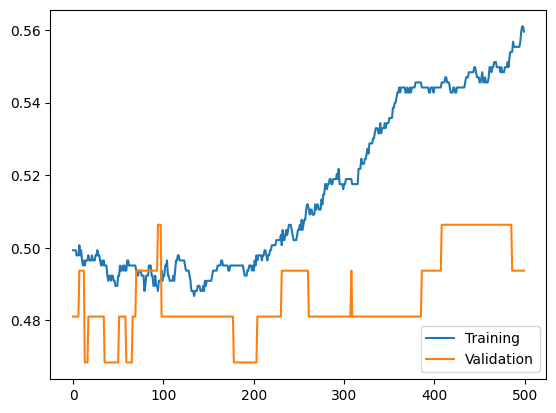

In [257]:
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']

plt.plot(range(epoch), acc, label='Training')
plt.plot(range(epoch), val_acc, label='Validation')
plt.legend(loc='lower right')

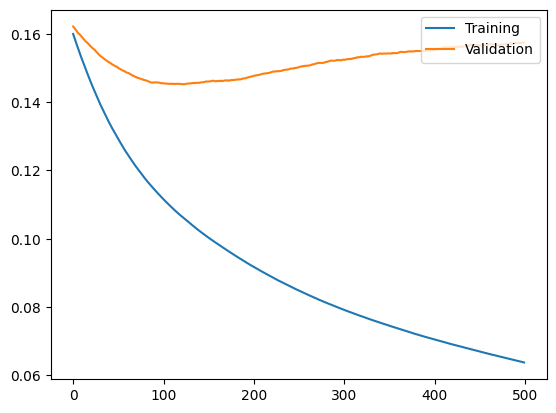

In [258]:
loss = historial.history['loss']
val_loss = historial.history['val_loss']

plt.plot(range(epoch), loss, label='Training')
plt.plot(range(epoch), val_loss, label='Validation')
plt.legend(loc='upper right')

In [259]:
score = modelo.evaluate(x_test, y_test, verbose=0)

print(f"Loss: {score[0]:.4f}")
print(f"Accuracy: {score[1]:.4f}")

Loss: 0.1574
Accuracy: 0.4937


3/3 [==============================] - 0s 2ms/step


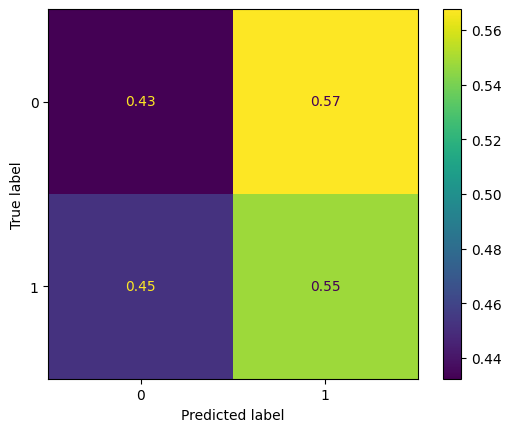

In [260]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = modelo.predict(x_test)

cf = confusion_matrix(y_test, list(map(np.argmax, y_pred)), normalize='true')
ConfusionMatrixDisplay(cf).plot()